# Image Compression

In [1]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

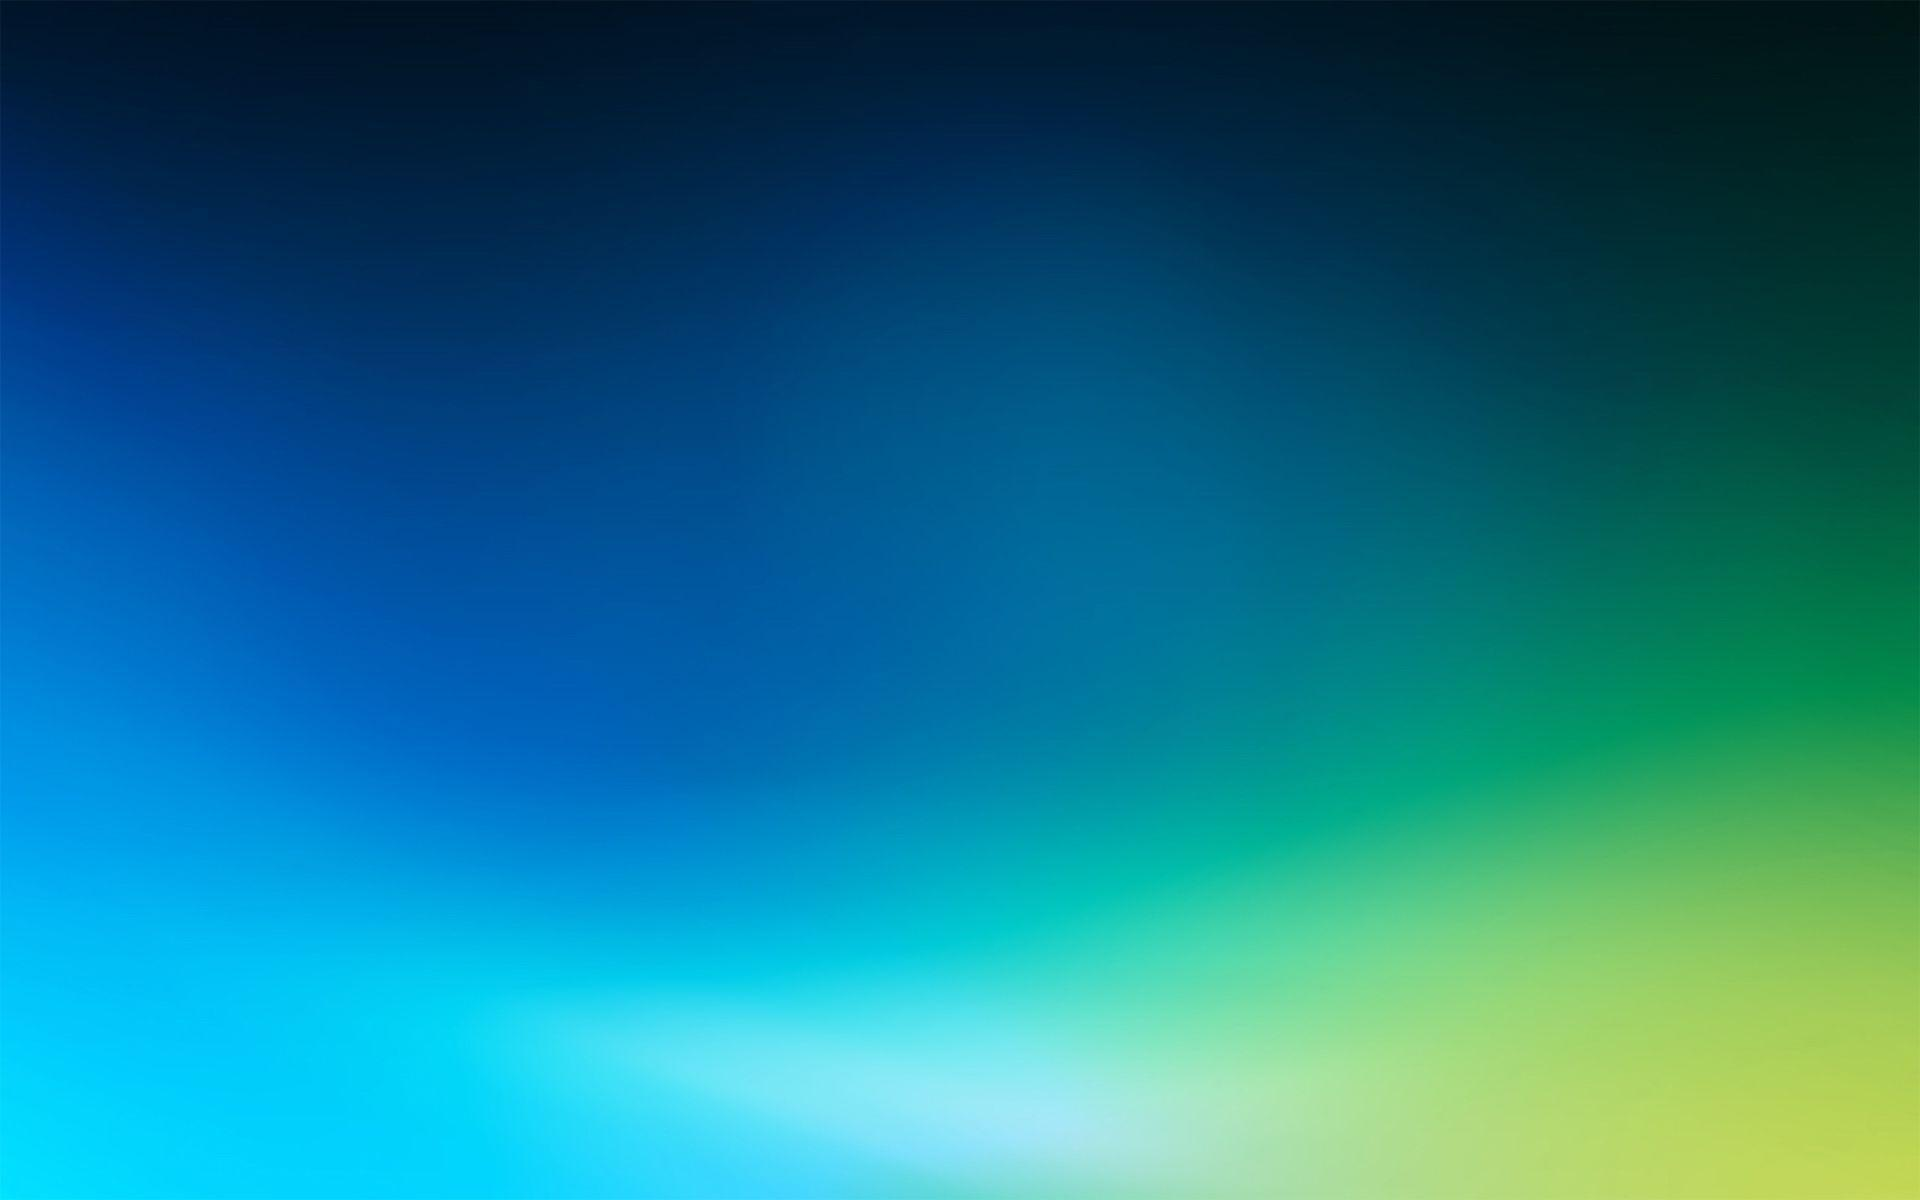

In [2]:
img = Image.open('img.jpg')
img

## Resize the image

We resize the image to make our model run faster.

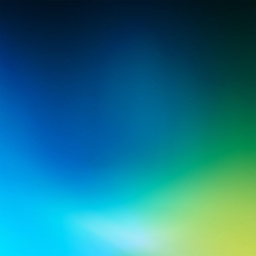

In [3]:
img = img.resize((256, 256))
img

## Convert to array

In [4]:
arr = np.array(img)
arr.shape

(256, 256, 3)

## Reshape Array

Now, we reshape the array into two dimensions. This is done so KMeans can work properly.

In [5]:
features = arr.reshape(-1, 3)
features.shape

(65536, 3)

## Find K

Now, we find the best K using the elbow method and silhoutte score.

### 1. Elbow Method

In [6]:
K = range(2, 11) # test K
inr = []  # store inertias
for i in K:
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(features)
    inr.append(kmeans.inertia_)
print(f'Inertias: {inr}')

Inertias: [362115141.7444071, 211105215.44926733, 126049088.16799122, 100683032.76027772, 80858647.53857149, 71223125.19235934, 57040331.27431707, 47743025.138555355, 43686886.60094014]


#### Plot graph

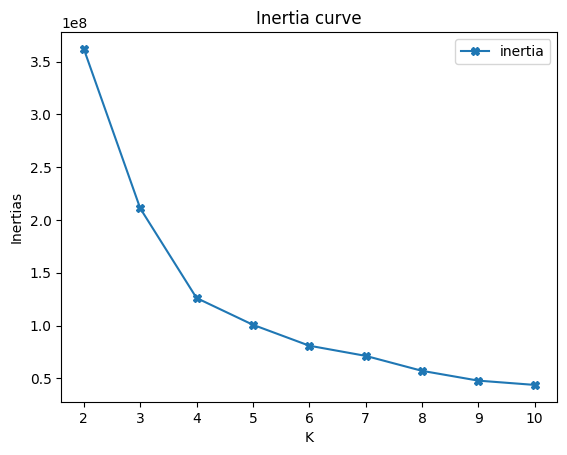

In [7]:
plt.plot(K, inr, label = 'inertia', marker = 'X')
plt.title('Inertia curve')
plt.xlabel('K')
plt.xticks(K)
plt.ylabel('Inertias')
plt.legend()
plt.show()

According to the graph, K should be either 4 or 5. Now, Let's check again with Silhoutte score.

### 2. Silhoutte Score

In [8]:
slh = []
K = range(2, 11)
for i in K:
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(features)
    slh.append(silhouette_score(features, labels))
max_score = slh.index(max(slh))
print(f'Scores: {slh}')
print(f'Max score: {slh[max_score]}, K: {K[max_score]}')

Scores: [0.4966096350698743, 0.49629821309723804, 0.5079114510782906, 0.502678274364183, 0.45496393366515586, 0.4413214024337144, 0.4752364011712315, 0.4626581492250116, 0.45811684975066425]
Max score: 0.5079114510782906, K: 4


### Conclusion

According to the graph and Silhouette Score, K = 4 should be the optimal solution.

## Training